# EEG alignment sweep report

This report summarizes the 12-run Things-EEG2 alignment sweep. The comparison varies aligned versus unaligned SynCLR targets, NICE versus ATMS EEG encoders, and seeds 41, 42, and 43.

`image_acc` is the primary metric here: EEG → image retrieval top-1 accuracy. `brain_acc` is retained as the reverse image → EEG retrieval accuracy.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
SWEEP_ROOT = PROJECT_ROOT / 'experiments' / 'eeg_alignment_sweep'
RESULTS_PATH = SWEEP_ROOT / 'aggregated_metrics.csv'
assert RESULTS_PATH.exists(), f'Missing sweep results: {RESULTS_PATH}'

results = pd.read_csv(RESULTS_PATH)
results = results.rename(columns={
    'eval/test/align/brain_acc': 'brain_acc',
    'eval/test/align/image_acc': 'image_acc',
    'eval/test/align/sim': 'sim',
    'model.align_img_encoder': 'target',
    'model.eeg_encoder.eeg_encoder': 'encoder',
    'model.seed': 'seed',
})
for column in ['brain_acc', 'image_acc', 'sim']:
    results[column] = pd.to_numeric(results[column])
results['seed'] = results['seed'].astype(int)
assert len(results) == 12, f'Expected 12 runs, found {len(results)}'
results.sort_values('image_acc', ascending=False).reset_index(drop=True)

,brain_acc,image_acc,sim,run,target,encoder,seed,dataset.subs
0,0.660,0.625,0.286136,20260830_231325_task4,aligned_synclr_vitb16,atms,42,[8]
1,0.660,0.595,0.277485,20260830_234005_task5,aligned_synclr_vitb16,atms,43,[8]
2,0.570,0.580,0.302921,20260831_021057_task11,unaligned_synclr_vitb16,atms,43,[8]
3,0.615,0.575,0.283186,20260830_224850_task3,aligned_synclr_vitb16,atms,41,[8]
4,0.605,0.555,0.270727,20260830_222039_task2,aligned_synclr_vitb16,nice,43,[8]
5,0.590,0.550,0.272238,20260830_215334_task1,aligned_synclr_vitb16,nice,42,[8]
6,0.590,0.530,0.300750,20260831_015314_task10,unaligned_synclr_vitb16,atms,42,[8]
7,0.560,0.525,0.291909,20260831_012757_task9,unaligned_synclr_vitb16,atms,41,[8]
8,0.575,0.520,0.288043,20260831_000903_task6,unaligned_synclr_vitb16,nice,41,[8]
9,0.555,0.505,0.290946,20260831_010735_task8,unaligned_synclr_vitb16,nice,43,[8]


## Per-run results

Runs are ranked by the primary EEG → image `image_acc` metric. The seed is shown explicitly.

In [2]:
per_run = (
    results[['target', 'encoder', 'seed', 'brain_acc', 'image_acc', 'sim', 'run']]
    .sort_values(['image_acc', 'brain_acc'], ascending=False)
    .reset_index(drop=True)
)
per_run.style.format({'brain_acc': '{:.3f}', 'image_acc': '{:.3f}', 'sim': '{:.4f}'})

,target,encoder,seed,brain_acc,image_acc,sim,run
0,aligned_synclr_vitb16,atms,42,0.660,0.625,0.2861,20260830_231325_task4
1,aligned_synclr_vitb16,atms,43,0.660,0.595,0.2775,20260830_234005_task5
2,unaligned_synclr_vitb16,atms,43,0.570,0.580,0.3029,20260831_021057_task11
3,aligned_synclr_vitb16,atms,41,0.615,0.575,0.2832,20260830_224850_task3
4,aligned_synclr_vitb16,nice,43,0.605,0.555,0.2707,20260830_222039_task2
5,aligned_synclr_vitb16,nice,42,0.590,0.550,0.2722,20260830_215334_task1
6,unaligned_synclr_vitb16,atms,42,0.590,0.530,0.3008,20260831_015314_task10
7,unaligned_synclr_vitb16,atms,41,0.560,0.525,0.2919,20260831_012757_task9
8,unaligned_synclr_vitb16,nice,41,0.575,0.520,0.2880,20260831_000903_task6
9,unaligned_synclr_vitb16,nice,43,0.555,0.505,0.2909,20260831_010735_task8


## Results across models

Mean and standard deviation are computed across the three seeds for each target/encoder pair.

In [3]:
summary = (
    results.groupby(['target', 'encoder'])[['brain_acc', 'image_acc', 'sim']]
    .agg(['mean', 'std'])
)
summary.round(4)

brain_acc         image_acc             sim  \
                                     mean     std      mean     std    mean   
target                  encoder                                               
aligned_synclr_vitb16   atms       0.6450  0.0260    0.5983  0.0252  0.2823   
                        nice       0.6033  0.0126    0.5283  0.0419  0.2702   
unaligned_synclr_vitb16 atms       0.5733  0.0153    0.5450  0.0304  0.2985   
                        nice       0.5550  0.0200    0.5067  0.0126  0.2872   

                                         
                                    std  
target                  encoder          
aligned_synclr_vitb16   atms     0.0044  
                        nice     0.0023  
unaligned_synclr_vitb16 atms     0.0058  
                        nice     0.0043

In [4]:
best = per_run.iloc[0]
print(
    f"Best image_acc run: {best['target']} + {best['encoder']} | "
    f"seed={best['seed']} | image_acc={best['image_acc']:.3f} | "
    f"brain_acc={best['brain_acc']:.3f}"
)
top_three = per_run.head(3)
top_three[['target', 'encoder', 'seed', 'brain_acc', 'image_acc', 'sim', 'run']]

Best image_acc run: aligned_synclr_vitb16 + atms | seed=42 | image_acc=0.625 | brain_acc=0.660


,target,encoder,seed,brain_acc,image_acc,sim,run
0,aligned_synclr_vitb16,atms,42,0.66,0.625,0.286136,20260830_231325_task4
1,aligned_synclr_vitb16,atms,43,0.66,0.595,0.277485,20260830_234005_task5
2,unaligned_synclr_vitb16,atms,43,0.57,0.580,0.302921,20260831_021057_task11


## Top-three retrieval visualizations

For each of the three highest-`image_acc` runs, show three saved target/chosen image pairs. Titles include the target, encoder, seed, and final `image_acc`. These are qualitative examples from the evaluator's saved outputs, not newly generated predictions.

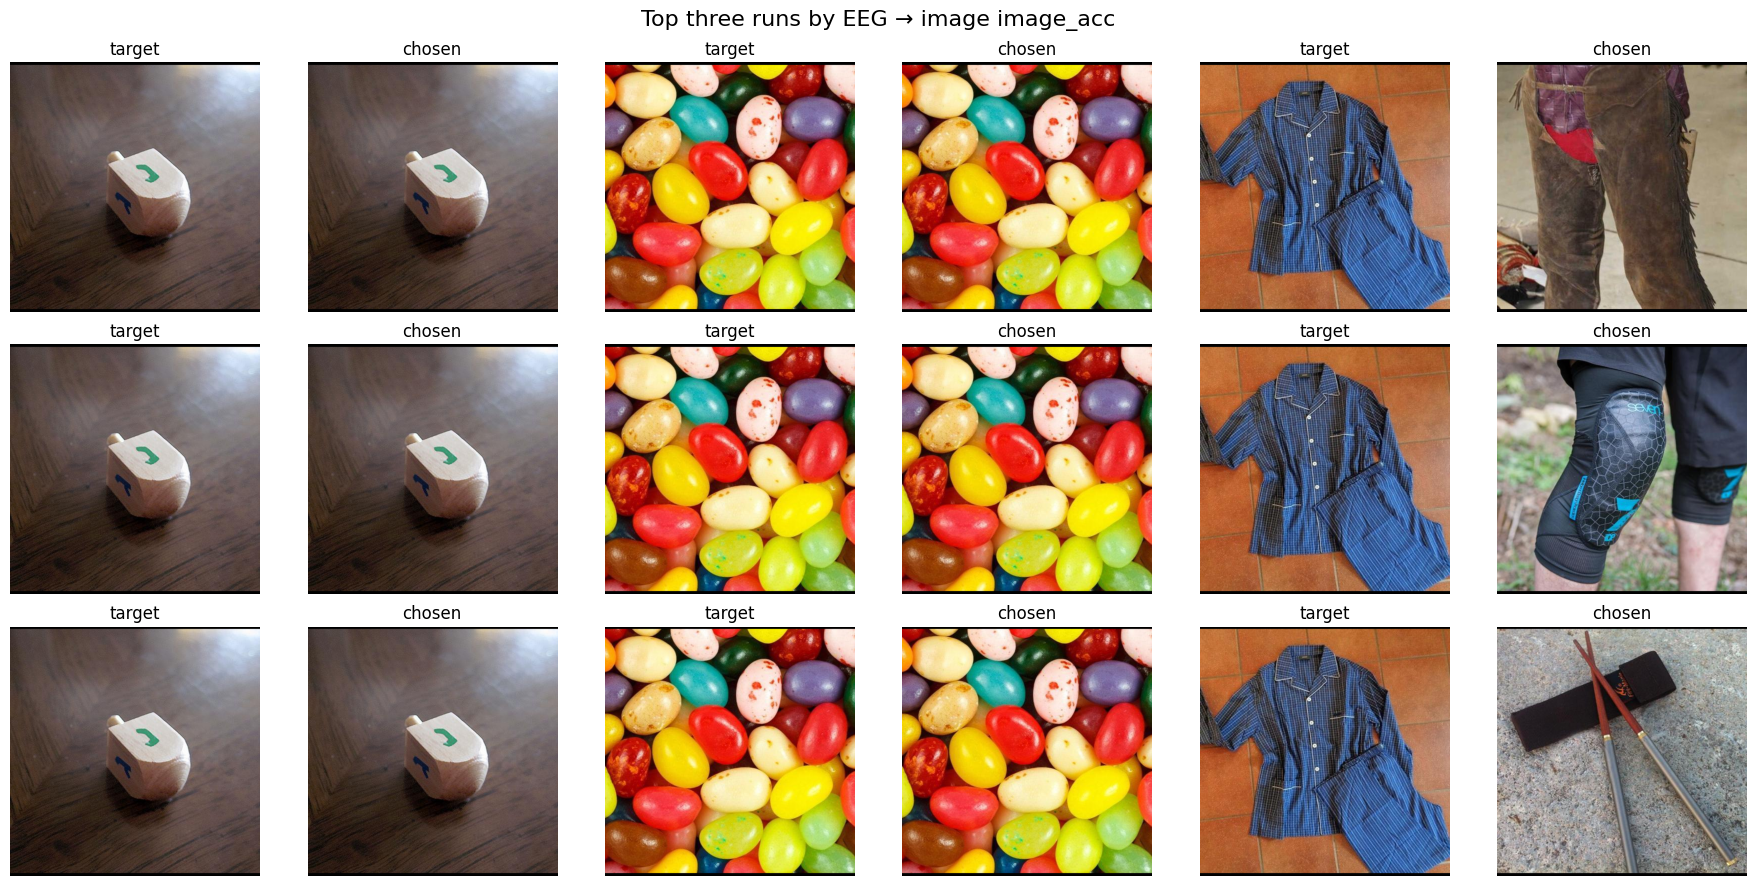

In [5]:
def find_test_dir(run_name: str) -> Path:
    matches = list((SWEEP_ROOT / run_name).glob('train_eeg-*/version_0/test'))
    if len(matches) != 1:
        raise FileNotFoundError(f'Expected one test directory for {run_name}, found {matches}')
    return matches[0]

def example_pairs(test_dir: Path, limit: int = 3):
    pairs = []
    for target_path in sorted(test_dir.glob('*/test/align/target.png')):
        chosen_path = target_path.with_name('chosen.png')
        if chosen_path.exists():
            pairs.append((target_path, chosen_path))
    return pairs[:limit]

fig, axes = plt.subplots(len(top_three), 6, figsize=(18, 9), squeeze=False)
for row_index, (_, run) in enumerate(top_three.iterrows()):
    pairs = example_pairs(find_test_dir(run['run']))
    if len(pairs) < 3:
        raise RuntimeError(f'Expected three image pairs for {run["run"]}')
    for pair_index, (target_path, chosen_path) in enumerate(pairs):
        target_axis = axes[row_index, pair_index * 2]
        chosen_axis = axes[row_index, pair_index * 2 + 1]
        target_axis.imshow(Image.open(target_path))
        chosen_axis.imshow(Image.open(chosen_path))
        target_axis.set_title('target')
        chosen_axis.set_title('chosen')
        target_axis.axis('off')
        chosen_axis.axis('off')
    axes[row_index, 0].set_ylabel(
        f"{run['encoder']}\n{run['target'].replace('_synclr_vitb16', '')}\n"
        f"seed={run['seed']}\nimage_acc={run['image_acc']:.3f}",
        rotation=0,
        labelpad=45,
        va='center',
    )
fig.suptitle('Top three runs by EEG → image image_acc', fontsize=16)
fig.tight_layout()
plt.show()